In [1]:
import pandas as pd
import numpy as np
import json
import os
import glob
import re
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from collections import Counter,  defaultdict
from plotly.subplots import make_subplots


FOLDER = "/content/drive/MyDrive/Colab Notebooks/Проектная школа 1 курс/TOP-5-ECO-Analysys"

In [2]:
files = glob.glob(os.path.join(FOLDER, "*.json"))

def normalize_osv_data_v2(data):
    vulns_list = []
    affected_list = []

    for vuln in data:
        db_specific = vuln.get('database_specific', {})
        if not isinstance(db_specific, dict):
            db_specific = {}

        # ИЗВЛЕЧЕНИЕ SEVERITY (три источника)
        severity_score = np.nan
        severity_string = ''

        # 1) Верхний уровень: severity[].type == CVSS_V3
        for sev in vuln.get('severity', []):
            if sev.get('type') == 'CVSS_V3':
                try:
                    severity_score = float(sev.get('score', 0))
                except:
                    pass

        # 2) GHSA: database_specific.severity строка
        if pd.isna(severity_score):
            severity_string = db_specific.get('severity', '')
            severity_map = {'CRITICAL': 9.5, 'HIGH': 7.5, 'MODERATE': 5.5, 'MEDIUM': 5.5, 'LOW': 2.5}
            severity_score = severity_map.get(severity_string.upper(), np.nan)

        # 3) OSS-Fuzz и подобные: affected[].ecosystem_specific.severity
        if pd.isna(severity_score):
            for aff in vuln.get('affected', []):
                eco_specific = aff.get('ecosystem_specific', {})
                if isinstance(eco_specific, dict):
                    sev_str = eco_specific.get('severity')
                    # Проверяем, что sev_str не None и не пустая строка
                    if sev_str and isinstance(sev_str, str) and sev_str.strip():
                        severity_string = sev_str
                        severity_map = {'CRITICAL': 9.5, 'HIGH': 7.5, 'MODERATE': 5.5, 'MEDIUM': 5.5, 'LOW': 2.5}
                        severity_score = severity_map.get(sev_str.upper(), np.nan)
                        break

        # ТАБЛИЦА УЯЗВИМОСТЕЙ
        vuln_record = {
            'id': vuln.get('id'),
            'schema_version': vuln.get('schema_version'),
            'published': vuln.get('published'),
            'modified': vuln.get('modified'),
            'withdrawn': vuln.get('withdrawn'),
            'summary': vuln.get('summary', '').strip() if vuln.get('summary') else '',
            'details': vuln.get('details', '').strip() if vuln.get('details') else '',
            'aliases': '|'.join(vuln.get('aliases', [])),
            'related': '|'.join(vuln.get('related', [])),
            'upstream': '|'.join(vuln.get('upstream', [])),
            'references_count': len(vuln.get('references', [])),
            'credits_count': len(vuln.get('credits', [])),
            'cvss_score': severity_score,
            'severity_string': severity_string,
            'cwe_ids': '|'.join(db_specific.get('cwe_ids', [])) if isinstance(db_specific.get('cwe_ids'), list) else '',
            'github_reviewed': db_specific.get('github_reviewed', False),
            'github_reviewed_at': db_specific.get('github_reviewed_at', ''),
            'nvd_published_at': db_specific.get('nvd_published_at', ''),
            'affected_count': len(vuln.get('affected', [])),
        }

        # Категория severity
        if pd.isna(severity_score):
            vuln_record['severity_category'] = 'UNKNOWN'
        elif severity_score >= 9.0:
            vuln_record['severity_category'] = 'CRITICAL'
        elif severity_score >= 7.0:
            vuln_record['severity_category'] = 'HIGH'
        elif severity_score >= 4.0:
            vuln_record['severity_category'] = 'MEDIUM'
        elif severity_score >= 0.1:
            vuln_record['severity_category'] = 'LOW'
        else:
            vuln_record['severity_category'] = 'NONE'

        # Проверка на fix
        has_any_fix = False
        for aff in vuln.get('affected', []):
            for rng in aff.get('ranges', []):
                for evt in rng.get('events', []):
                    if 'fixed' in evt and evt['fixed']:
                        has_any_fix = True
                        break
        vuln_record['has_any_fix'] = has_any_fix

        vulns_list.append(vuln_record)

        # ТАБЛИЦА ЗАТРОНУТЫХ ПАКЕТОВ
        for aff_idx, aff in enumerate(vuln.get('affected', [])):
            pkg = aff.get('package', {})
            aff_record = {
                'vulnerability_id': vuln.get('id'),
                'package_ecosystem': pkg.get('ecosystem', ''),
                'package_name': pkg.get('name', ''),
                'package_purl': pkg.get('purl', ''),
                'affected_index': aff_idx,
            }
            has_fix = False
            fix_versions = []
            for rng in aff.get('ranges', []):
                for evt in rng.get('events', []):
                    if 'fixed' in evt and evt['fixed']:
                        has_fix = True
                        fix_versions.append(evt['fixed'])
            aff_record['has_fix'] = has_fix
            aff_record['fix_versions'] = '|'.join(fix_versions) if fix_versions else None
            aff_record['versions_count'] = len(aff.get('versions', []))
            affected_list.append(aff_record)

    vulns_df = pd.DataFrame(vulns_list)
    affected_df = pd.DataFrame(affected_list)

    for col in ['published', 'modified', 'withdrawn', 'nvd_published_at', 'github_reviewed_at']:
        if col in vulns_df.columns:
            vulns_df[col] = pd.to_datetime(vulns_df[col], format='mixed', errors='coerce', utc=True)

    vulns_df['days_to_modify'] = (vulns_df['modified'] - vulns_df['published']).dt.days
    vulns_df['is_withdrawn'] = vulns_df['withdrawn'].notna()
    vulns_df['publication_year'] = vulns_df['published'].dt.year
    vulns_df['publication_month'] = vulns_df['published'].dt.month
    vulns_df['source'] = vulns_df['id'].str.split('-').str[0]

    return vulns_df, affected_df

# Перезагружаем все файлы с исправленной функцией
all_vulns = {}
all_affected = {}

for filepath in sorted(files):
    filename = os.path.basename(filepath).replace('Копия ', '').replace('.json', '')
    with open(filepath, 'r') as f:
        data = json.load(f)

    print(f"Обработка: {filename} ({len(data):,} записей)...")
    vulns_df, affected_df = normalize_osv_data_v2(data)
    all_vulns[filename] = vulns_df
    all_affected[filename] = affected_df


Обработка: Go_vulnerabilities (6,946 записей)...
Обработка: Maven_vulnerabilities (6,576 записей)...
Обработка: OSS-Fuzz_vulnerabilities (4,100 записей)...
Обработка: PyPI_vulnerabilities (19,564 записей)...
Обработка: npm_vulnerabilities (218,679 записей)...


In [3]:
for name in all_vulns.keys():
    v = all_vulns[name]
    a = all_affected[name]
    print(f"  {name}: {v.shape[0]:,} уязвимостей, {a.shape[0]:,} affected")

  Go_vulnerabilities: 6,946 уязвимостей, 11,021 affected
  Maven_vulnerabilities: 6,576 уязвимостей, 11,717 affected
  OSS-Fuzz_vulnerabilities: 4,100 уязвимостей, 4,100 affected
  PyPI_vulnerabilities: 19,564 уязвимостей, 24,900 affected
  npm_vulnerabilities: 218,679 уязвимостей, 221,007 affected


In [4]:
# Добавляем метку экосистемы и объединяем всё в один DataFrame
all_vulns_combined = []

for name, df in all_vulns.items():
    # Определяем экосистему по имени файла
    if 'PyPI' in name:
        eco = 'PyPI'
    elif 'npm' in name:
        eco = 'npm'
    elif 'Go' in name:
        eco = 'Go'
    elif 'OSS-Fuzz' in name:
        eco = 'OSS-Fuzz'
    elif 'Maven' in name:
        eco = 'Maven'
    else:
        eco = name

    df_copy = df.copy()
    df_copy['ecosystem'] = eco
    all_vulns_combined.append(df_copy)

combined_vulns = pd.concat(all_vulns_combined, ignore_index=True)


print(f"Всего записей: {len(combined_vulns):,}")
print()

# Экосистема × Источник
crosstab = pd.crosstab(combined_vulns['ecosystem'], combined_vulns['source'])

# Стилизация
styled1 = crosstab.style\
    .background_gradient(cmap='Blues', axis=None)\
    .set_caption("Распределение записей по экосистемам и источникам")\
    .format("{:,}")\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '8px')]}
    ])



display(styled1)

# Экосистема × Severity
crosstab2 = pd.crosstab(combined_vulns['ecosystem'], combined_vulns['severity_category'])

# Переупорядочим колонки severity по убыванию критичности
severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'NONE', 'UNKNOWN']
existing_cols = [col for col in severity_order if col in crosstab2.columns]
crosstab2 = crosstab2[existing_cols]

styled2 = crosstab2.style\
    .background_gradient(cmap='Reds', axis=None, subset=['CRITICAL', 'HIGH'])\
    .background_gradient(cmap='YlOrBr', axis=None, subset=['MEDIUM'])\
    .background_gradient(cmap='Greens', axis=None, subset=['LOW'])\
    .background_gradient(cmap='Greys', axis=None, subset=['UNKNOWN'])\
    .set_caption("Распределение severity по экосистемам")\
    .format("{:,}")\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '8px')]}
    ])

display(styled2)

Всего записей: 255,865



source,GHSA,GO,GSD,MAL,OSV,PYSEC
ecosystem,,,,,,
Go,"3,816","3,111",0,18,1,0
Maven,"6,574",0,0,2,0,0
OSS-Fuzz,0,0,0,0,"4,100",0
PyPI,"5,088",0,0,"11,156",8,"3,312"
npm,"6,201",0,1,"212,477",0,0


severity_category,CRITICAL,HIGH,MEDIUM,LOW,UNKNOWN
ecosystem,,,,,
Go,421,"1,411","1,701",284,"3,129"
Maven,881,"2,135","3,169",388,3
OSS-Fuzz,0,"1,086","2,289",267,458
PyPI,633,"1,951","2,074",435,"14,471"
npm,"1,257","2,395","2,154",394,"212,479"


In [9]:
import pandas as pd
import numpy as np

# GHSA + OSS-Fuzz
ghsa_and_fuzz = combined_vulns[
    (combined_vulns['source'] == 'GHSA') |
    ((combined_vulns['ecosystem'] == 'OSS-Fuzz') & (combined_vulns['severity_category'] != 'UNKNOWN'))
].copy()

# ===== ЧАСТЬ 1: Severity-микс (вес 0.7) =====
crosstab2 = pd.crosstab(ghsa_and_fuzz['ecosystem'], ghsa_and_fuzz['severity_category'])
severity_cols = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
crosstab2_frac = crosstab2[severity_cols].div(crosstab2[severity_cols].sum(axis=1), axis=0)

severity_score = (
    crosstab2_frac['CRITICAL'] * 100 +
    crosstab2_frac['HIGH'] * 70 +
    crosstab2_frac['MEDIUM'] * 50 +
    crosstab2_frac['LOW'] * 20
)

# Unfix rate по каждой severity
# Считаем % неисправленных для каждого severity × экосистема
unfix_by_sev = ghsa_and_fuzz.groupby(['ecosystem', 'severity_category'])['has_any_fix'].agg(lambda x: 1 - x.mean())

# Разворачиваем в таблицу: строки=экосистемы, колонки=severity
unfix_table = unfix_by_sev.unstack(fill_value=0)

# Взвешиваем unfix_rate с теми же множителями
weights = {'CRITICAL': 1.0, 'HIGH': 0.7, 'MEDIUM': 0.5, 'LOW': 0.2}
unfix_score = 0
for cat in severity_cols:
    if cat in unfix_table.columns:
        unfix_score += unfix_table[cat] * 100 * weights[cat]  # *100 чтобы проценты

# ИТОГОВЫЙ SCORE
score_df = pd.DataFrame({
    'severity_score': severity_score,
    'unfix_score': unfix_score,
    'total_vulns': ghsa_and_fuzz.groupby('ecosystem').size()
})

score_df['final_score'] = (
    score_df['severity_score'] * 0.7 +
    score_df['unfix_score'] * 0.3
)

score_df = score_df.dropna().sort_values('final_score', ascending=False)

print("COMPOSITE SCORE ЭКОСИСТЕМ (GHSA + OSS-Fuzz)")
print()
print("Формула: (SeverityScore)*0.7 + (WeightedUnfixScore)*0.3")
print("Unfix множители: CRIT=1.0, HIGH=0.7, MED=0.5, LOW=0.2")
print("Чем выше — тем экосистема опаснее")
print()
print(f"{'Экосистема':20s} {'Уязв.':>6s} {'SevScore':>8s} {'UnfixSc':>8s} {'FINAL':>8s}")
print("-" * 55)
for eco in score_df.index:
    row = score_df.loc[eco]
    print(f"{eco:20s} {int(row['total_vulns']):6d} {row['severity_score']:7.1f} {row['unfix_score']:7.1f} {row['final_score']:7.1f}")

# Детализация unfix по severity
print("ДЕТАЛИЗАЦИЯ: % НЕИСПРАВЛЕННЫХ ПО SEVERITY")
print(f"{'Экосистема':20s} {'CRIT%':>8s} {'HIGH%':>8s} {'MED%':>8s} {'LOW%':>8s} {'Взвеш.':>8s}")
print("-" * 66)
for eco in score_df.index:
    row_data = []
    for cat in severity_cols:
        if cat in unfix_table.columns:
            row_data.append(f"{unfix_table.loc[eco, cat]*100:5.0f}%")
        else:
            row_data.append(f"{'—':>5s}")
    print(f"{eco:20s} {row_data[0]:>8s} {row_data[1]:>8s} {row_data[2]:>8s} {row_data[3]:>8s} {score_df.loc[eco, 'unfix_score']:7.1f}")

COMPOSITE SCORE ЭКОСИСТЕМ (GHSA + OSS-Fuzz)

Формула: (SeverityScore)*0.7 + (WeightedUnfixScore)*0.3
Unfix множители: CRIT=1.0, HIGH=0.7, MED=0.5, LOW=0.2
Чем выше — тем экосистема опаснее

Экосистема            Уязв. SevScore  UnfixSc    FINAL
-------------------------------------------------------
npm                    6201    66.0    74.6    68.5
Maven                  6574    61.4    38.3    54.5
PyPI                   5088    61.3    33.2    52.9
Go                     3816    60.7    25.5    50.1
OSS-Fuzz               3642    53.8    18.0    43.0
ДЕТАЛИЗАЦИЯ: % НЕИСПРАВЛЕННЫХ ПО SEVERITY
Экосистема              CRIT%    HIGH%     MED%     LOW%   Взвеш.
------------------------------------------------------------------
npm                       48%      24%      13%      16%    74.6
Maven                     13%      15%      18%      29%    38.3
PyPI                      16%      12%      11%      13%    33.2
Go                        12%      10%       9%      10%    25.5
OSS-

In [10]:
# Выделяем только GHSA из трёх экосистем
ghsa_mask = combined_vulns['source'] == 'GHSA'
eco_mask = combined_vulns['ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven'])
ghsa_clean = combined_vulns[ghsa_mask & eco_mask].copy()

print()
print("GHSA — Смотрим только по ней")



# Базовая статистика по каждой экосистеме
for eco in ['PyPI', 'npm', 'Go', 'Maven']:
    subset = ghsa_clean[ghsa_clean['ecosystem'] == eco]
    print(f"\n{'--' * 40}")
    print(f"{eco}")
    print(f"{'--' * 40}")
    print(f"  Всего уязвимостей: {len(subset):,}")
    print(f"  Период: {int(subset['publication_year'].min())} – {int(subset['publication_year'].max())}")
    print(f"  Медианный CVSS: {subset['cvss_score'].median():.1f}")
    print(f"  Исправлено: {subset['has_any_fix'].sum():,} ({subset['has_any_fix'].mean()*100:.1f}%)")
    print(f"  Отозвано: {subset['is_withdrawn'].sum():,}")
    print(f"  Среднее references: {subset['references_count'].mean():.1f}")

print(f"\n{'-' * 60}")
print(f"ИТОГО GHSA: {len(ghsa_clean):,} уязвимостей")


GHSA — Смотрим только по ней

--------------------------------------------------------------------------------
PyPI
--------------------------------------------------------------------------------
  Всего уязвимостей: 5,088
  Период: 2018 – 2026
  Медианный CVSS: 7.5
  Исправлено: 4,453 (87.5%)
  Отозвано: 92
  Среднее references: 6.6

--------------------------------------------------------------------------------
npm
--------------------------------------------------------------------------------
  Всего уязвимостей: 6,201
  Период: 2017 – 2026
  Медианный CVSS: 7.5
  Исправлено: 4,676 (75.4%)
  Отозвано: 267
  Среднее references: 4.6

--------------------------------------------------------------------------------
Go
--------------------------------------------------------------------------------
  Всего уязвимостей: 3,816
  Период: 2021 – 2026
  Медианный CVSS: 5.5
  Исправлено: 3,443 (90.2%)
  Отозвано: 75
  Среднее references: 5.5

-----------------------------------------------

In [11]:
# SEVERITY: СРАВНЕНИЕ ЭКОСИСТЕМ (GROUPED BAR)
severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
eco_list = ['PyPI', 'npm', 'Go', 'Maven', 'OSS-Fuzz']

colors = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0', 'OSS-Fuzz': '#FF5722'}

fig1 = go.Figure()
for eco in eco_list:
    subset = ghsa_clean[ghsa_clean['ecosystem'] == eco] if eco != 'OSS-Fuzz' else combined_vulns[combined_vulns['ecosystem'] == 'OSS-Fuzz']
    pcts = []
    for cat in severity_order:
        pct = (subset['severity_category'] == cat).mean() * 100
        pcts.append(pct)
    fig1.add_trace(go.Bar(x=severity_order, y=pcts, name=eco,
                          marker_color=colors[eco],
                          text=[f'{p:.1f}%' for p in pcts], textposition='outside'))

fig1.update_layout(title="1. Распределение severity по экосистемам",
                   yaxis_title="% уязвимостей", height=500)
fig1.show()

# FIX RATE + СРЕДНИЙ CVSS
fig2 = make_subplots(specs=[[{"secondary_y": True}]])

# Собираем статистику для всех экосистем
all_eco_stats = []
for eco in eco_list:
    if eco == 'OSS-Fuzz':
        subset = combined_vulns[combined_vulns['ecosystem'] == 'OSS-Fuzz']
    else:
        subset = ghsa_clean[ghsa_clean['ecosystem'] == eco]

    all_eco_stats.append({
        'ecosystem': eco,
        'fix_rate': subset['has_any_fix'].mean() * 100,
        'avg_cvss': subset['cvss_score'].mean()
    })

eco_stats = pd.DataFrame(all_eco_stats)

fig2.add_trace(go.Bar(x=eco_stats['ecosystem'], y=eco_stats['fix_rate'], name='% исправленных',
                      marker_color=[colors[eco] for eco in eco_stats['ecosystem']],
                      text=eco_stats['fix_rate'].round(1).astype(str)+'%',
                      textposition='outside'), secondary_y=False)
fig2.add_trace(go.Scatter(x=eco_stats['ecosystem'], y=eco_stats['avg_cvss'], name='Средний CVSS',
                          mode='markers+lines', marker=dict(size=20, color='red'),
                          line=dict(width=3, color='red')), secondary_y=True)

fig2.update_layout(title="2. Fix rate и средний CVSS по экосистемам", height=450)
fig2.update_yaxes(title_text="% исправленных", range=[0, 100], secondary_y=False)
fig2.update_yaxes(title_text="Средний CVSS", range=[0, 10], secondary_y=True)
fig2.show()

# МЕДИАННОЕ ВРЕМЯ МОДИФИКАЦИИ
time_stats = []
for eco in eco_list:
    if eco == 'OSS-Fuzz':
        subset = combined_vulns[combined_vulns['ecosystem'] == 'OSS-Fuzz']
    else:
        subset = ghsa_clean[ghsa_clean['ecosystem'] == eco]
    time_stats.append({
        'ecosystem': eco,
        'days_to_modify': subset['days_to_modify'].median()
    })

time_stats_df = pd.DataFrame(time_stats)

fig3 = go.Figure(go.Bar(x=time_stats_df['ecosystem'], y=time_stats_df['days_to_modify'],
                         marker_color=[colors[eco] for eco in time_stats_df['ecosystem']],
                         text=time_stats_df['days_to_modify'].round().astype(int).astype(str)+' дн.',
                         textposition='outside'))
fig3.update_layout(title="3. Медианное время модификации по экосистемам",
                   yaxis_title="Медианное время (дни)", height=450)
fig3.show()

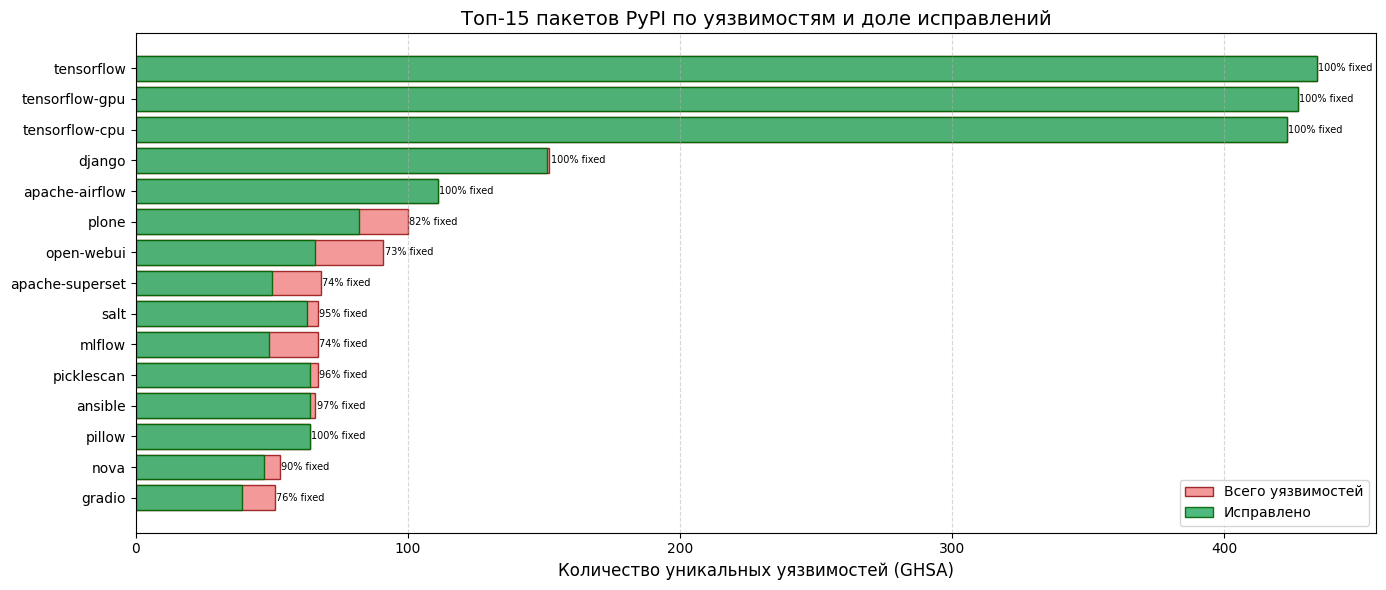

In [12]:
pyPI_ids = ghsa_clean[ghsa_clean['ecosystem'] == 'PyPI']['id'].tolist()
# affected_df из PyPI
pyPI_affected = all_affected['PyPI_vulnerabilities'].copy()
pyPI_affected = pyPI_affected[pyPI_affected['vulnerability_id'].isin(pyPI_ids)]

pkg_stats_pypi = pyPI_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()

top_pypi = pkg_stats_pypi.nlargest(15, 'unique_vulns')

# Сортируем для красивого графика
top_pypi_sorted = top_pypi.sort_values('unique_vulns', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))

# Основные бары — общее количество уязвимостей
bars = ax.barh(
    top_pypi_sorted['package_name'],
    top_pypi_sorted['unique_vulns'],
    color='lightcoral',
    edgecolor='darkred',
    alpha=0.8,
    label='Всего уязвимостей'
)

# Наложим исправленные уязвимости поверх (другой цвет)
fixed_counts = (top_pypi_sorted['unique_vulns'] * top_pypi_sorted['fix_rate']).astype(int)
ax.barh(
    top_pypi_sorted['package_name'],
    fixed_counts,
    color='mediumseagreen',
    edgecolor='darkgreen',
    alpha=0.9,
    label='Исправлено'
)

# Подпишем проценты справа от баров
for i, (val, rate) in enumerate(zip(top_pypi_sorted['unique_vulns'],
                                     top_pypi_sorted['fix_rate'])):
    ax.text(val + 0.5, i, f'{rate*100:.0f}% fixed',
            va='center', fontsize=7, color='black')

ax.set_xlabel('Количество уникальных уязвимостей (GHSA)', fontsize=12)
ax.set_title('Топ-15 пакетов PyPI по уязвимостям и доле исправлений', fontsize=14)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

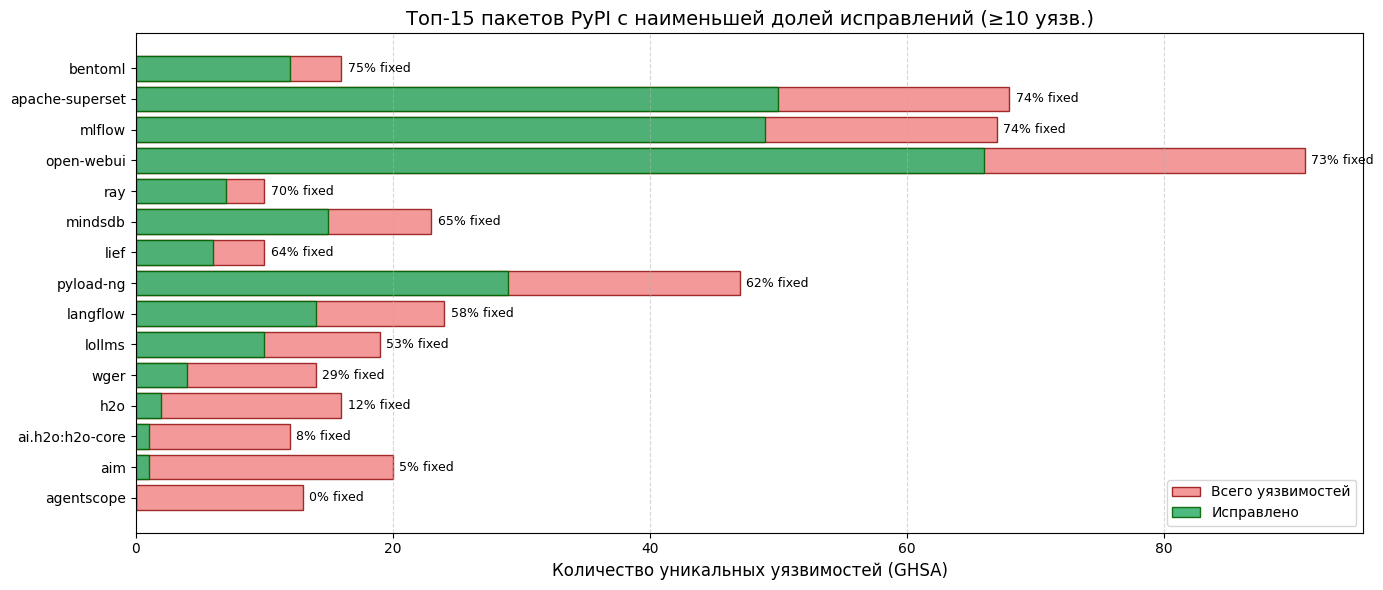

In [13]:
# Худшие по fix_rate (меньше всего исправлений)
worst_pypi = pkg_stats_pypi[pkg_stats_pypi['unique_vulns'] >= 10].nsmallest(15, 'fix_rate')

# Сортируем по fix_rate для красивого графика
worst_pypi_sorted = worst_pypi.sort_values('fix_rate', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))

# Основные бары — общее количество уязвимостей
bars = ax.barh(
    worst_pypi_sorted['package_name'],
    worst_pypi_sorted['unique_vulns'],
    color='lightcoral',
    edgecolor='darkred',
    alpha=0.8,
    label='Всего уязвимостей'
)

# Наложим исправленные уязвимости поверх
fixed_counts = (worst_pypi_sorted['unique_vulns'] * worst_pypi_sorted['fix_rate']).astype(int)
ax.barh(
    worst_pypi_sorted['package_name'],
    fixed_counts,
    color='mediumseagreen',
    edgecolor='darkgreen',
    alpha=0.9,
    label='Исправлено'
)

# Подпишем проценты справа
for i, (val, rate) in enumerate(zip(worst_pypi_sorted['unique_vulns'],
                                     worst_pypi_sorted['fix_rate'])):
    ax.text(val + 0.5, i, f'{rate*100:.0f}% fixed',
            va='center', fontsize=9, color='black')

ax.set_xlabel('Количество уникальных уязвимостей (GHSA)', fontsize=12)
ax.set_title('Топ-15 пакетов PyPI с наименьшей долей исправлений (≥10 уязв.)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
def plot_top_packages(top_df, ecosystem_name):
    top_sorted = top_df.sort_values('unique_vulns', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Всего уязвимостей
    ax.barh(
        top_sorted['package_name'],
        top_sorted['unique_vulns'],
        color='lightcoral',
        edgecolor='darkred',
        alpha=0.8,
        label='Всего уязвимостей'
    )

    # Исправлено
    fixed_counts = (top_sorted['unique_vulns'] * top_sorted['fix_rate']).astype(int)
    ax.barh(
        top_sorted['package_name'],
        fixed_counts,
        color='mediumseagreen',
        edgecolor='darkgreen',
        alpha=0.9,
        label='Исправлено'
    )

    # Проценты
    for i, (val, rate) in enumerate(zip(top_sorted['unique_vulns'],
                                         top_sorted['fix_rate'])):
        ax.text(val + 0.5, i, f'{rate*100:.0f}%',
                va='center', fontsize=9, color='black')

    ax.set_xlabel('Количество уникальных уязвимостей (GHSA)', fontsize=12)
    ax.set_title(f'Топ-15 пакетов {ecosystem_name} по уязвимостям и доле исправлений', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

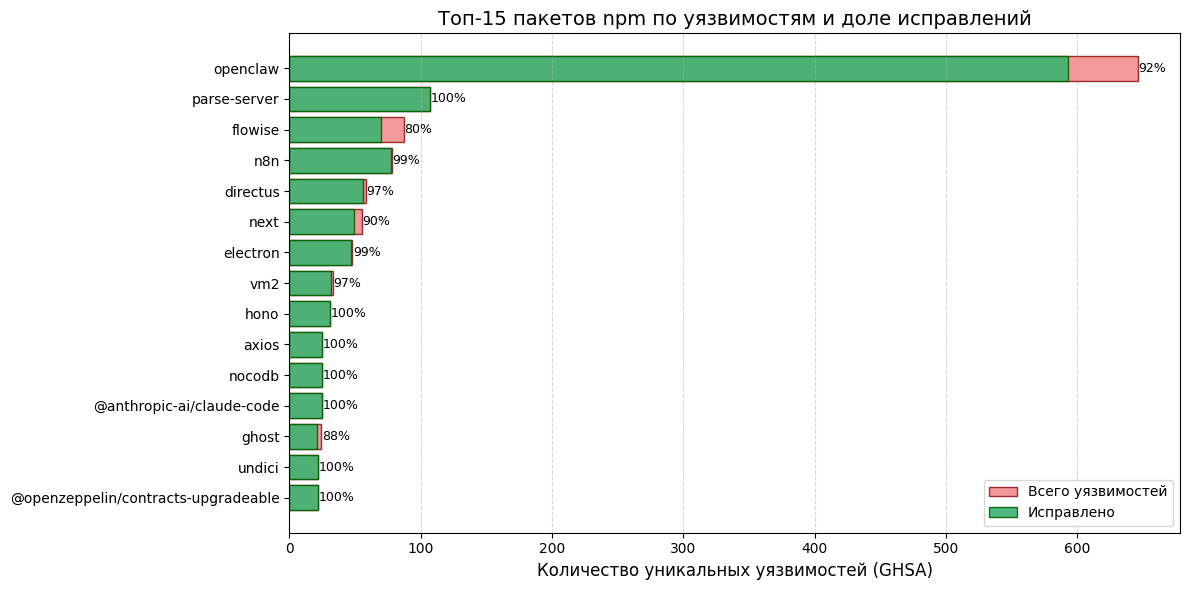

In [15]:
npm_ids = ghsa_clean[ghsa_clean['ecosystem'] == 'npm']['id'].tolist()
npm_affected = all_affected['npm_vulnerabilities'].copy()
npm_affected = npm_affected[npm_affected['vulnerability_id'].isin(npm_ids)]

pkg_stats_npm = npm_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()

top_npm = pkg_stats_npm.nlargest(15, 'unique_vulns')
plot_top_packages(top_npm, 'npm')

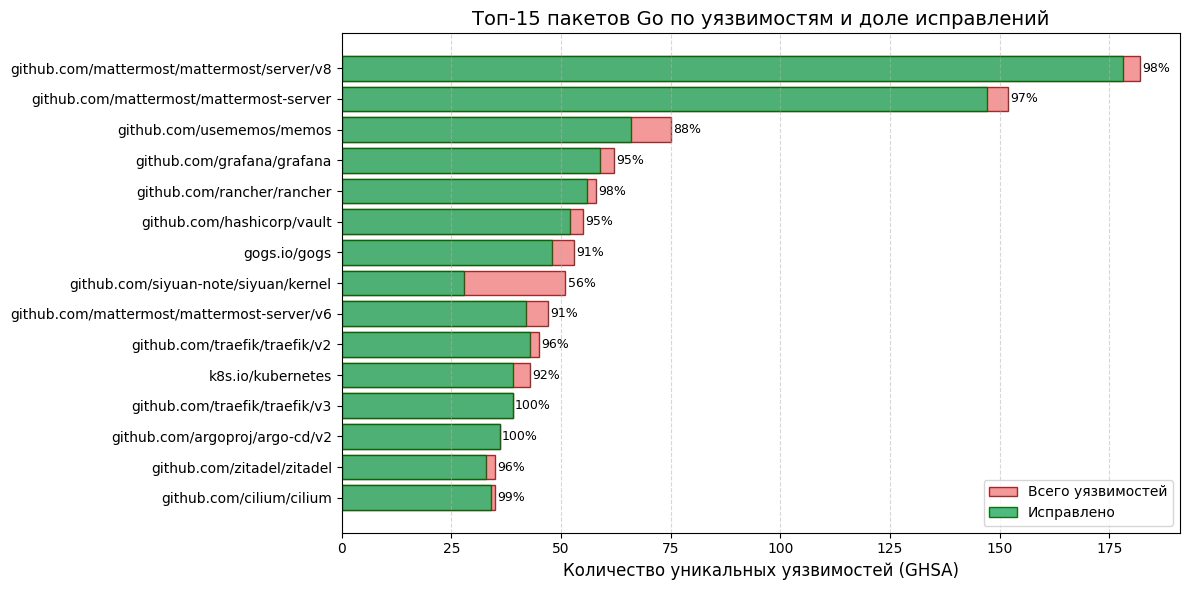

In [16]:
go_ids = ghsa_clean[ghsa_clean['ecosystem'] == 'Go']['id'].tolist()
go_affected = all_affected['Go_vulnerabilities'].copy()
go_affected = go_affected[go_affected['vulnerability_id'].isin(go_ids)]

pkg_stats_go = go_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()

top_go = pkg_stats_go.nlargest(15, 'unique_vulns')
plot_top_packages(top_go, 'Go')

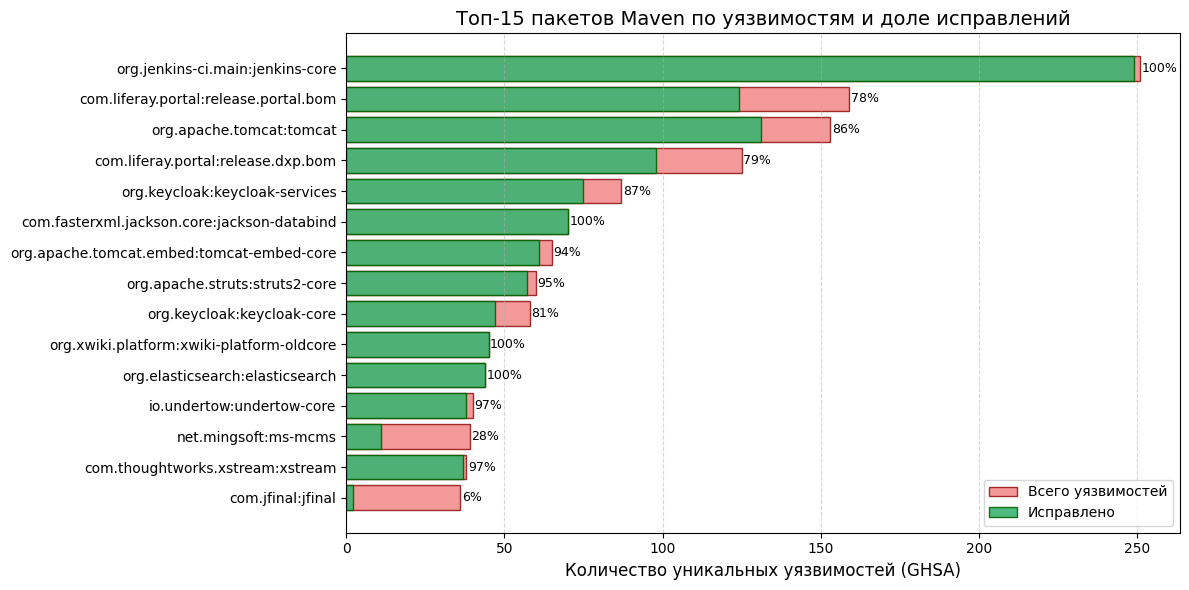

In [17]:
maven_ids = ghsa_clean[ghsa_clean['ecosystem'] == 'Maven']['id'].tolist()
maven_affected = all_affected['Maven_vulnerabilities'].copy()
maven_affected = maven_affected[maven_affected['vulnerability_id'].isin(maven_ids)]

pkg_stats_maven = maven_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()

top_maven = pkg_stats_maven.nlargest(15, 'unique_vulns')
plot_top_packages(top_maven, 'Maven')

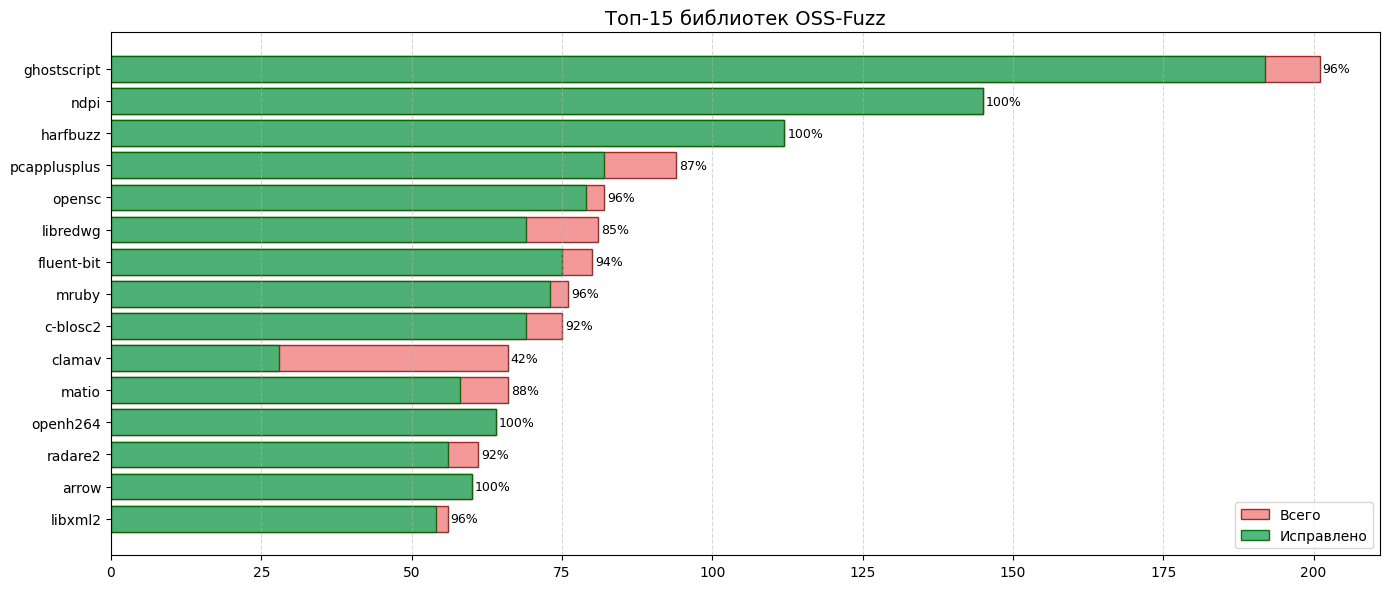

In [23]:
# OSS-Fuzz из combined_vulns
fuzz_ids = combined_vulns[combined_vulns['ecosystem'] == 'OSS-Fuzz']['id'].tolist()

# Берём affected из all_affected
fuzz_affected = all_affected['OSS-Fuzz_vulnerabilities'].copy()
fuzz_affected = fuzz_affected[fuzz_affected['vulnerability_id'].isin(fuzz_ids)]

pkg_stats_fuzz = fuzz_affected.groupby('package_name').agg(
    unique_vulns=('vulnerability_id', 'nunique'),
    fix_rate=('has_fix', 'mean')
).reset_index()

top_fuzz = pkg_stats_fuzz.nlargest(15, 'unique_vulns').sort_values('unique_vulns', ascending=True)

# График
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top_fuzz['package_name'], top_fuzz['unique_vulns'], color='lightcoral', edgecolor='darkred', alpha=0.8, label='Всего')
fixed = (top_fuzz['unique_vulns'] * top_fuzz['fix_rate']).astype(int)
ax.barh(top_fuzz['package_name'], fixed, color='mediumseagreen', edgecolor='darkgreen', alpha=0.9, label='Исправлено')
for i, (val, rate) in enumerate(zip(top_fuzz['unique_vulns'], top_fuzz['fix_rate'])):
    ax.text(val + 0.5, i, f'{rate*100:.0f}%', va='center', fontsize=9)
ax.set_title('Топ-15 библиотек OSS-Fuzz', fontsize=14)
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

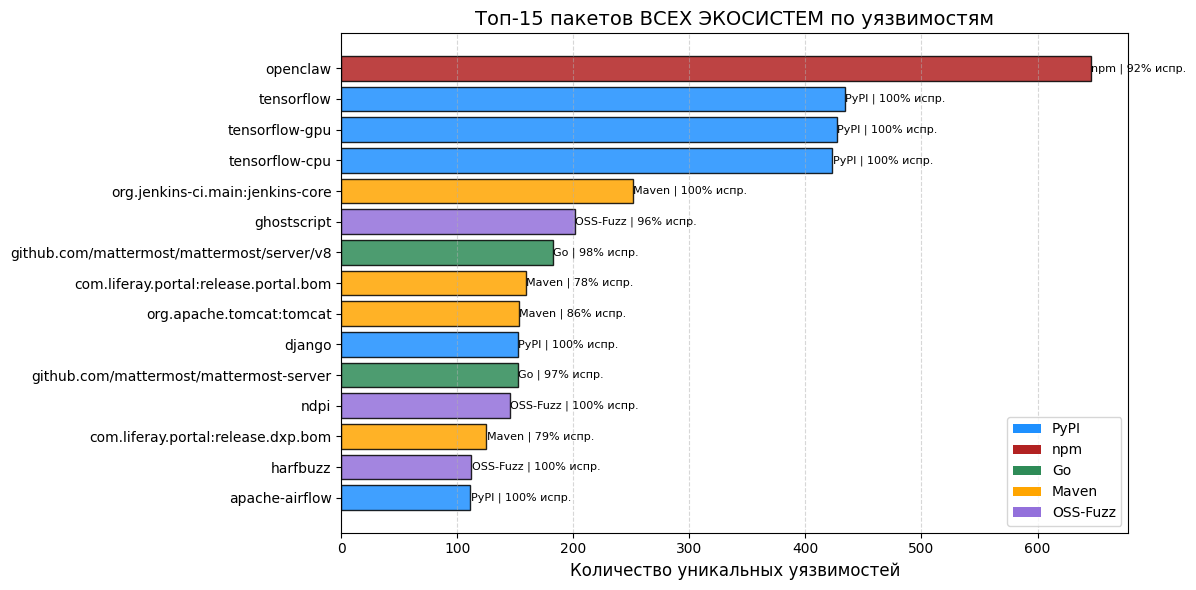

In [24]:
pkg_stats_pypi['ecosystem'] = 'PyPI'
pkg_stats_npm['ecosystem'] = 'npm'
pkg_stats_go['ecosystem'] = 'Go'
pkg_stats_maven['ecosystem'] = 'Maven'
pkg_stats_fuzz['ecosystem'] = 'OSS-Fuzz'

all_pkg_stats = pd.concat([pkg_stats_pypi, pkg_stats_npm, pkg_stats_go, pkg_stats_maven, pkg_stats_fuzz],
                          ignore_index=True)
top_all = all_pkg_stats.nlargest(15, 'unique_vulns')

# Цвета по экосистемам
top_all_sorted = top_all.sort_values('unique_vulns', ascending=True)
eco_colors = {
    'PyPI': 'dodgerblue',
    'npm': 'firebrick',
    'Go': 'seagreen',
    'Maven': 'orange',
    'OSS-Fuzz': 'mediumpurple'
}
bar_colors = [eco_colors[eco] for eco in top_all_sorted['ecosystem']]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_all_sorted['package_name'], top_all_sorted['unique_vulns'],
        color=bar_colors, edgecolor='black', alpha=0.85)

# Подписи
for i, (val, eco, rate) in enumerate(zip(top_all_sorted['unique_vulns'],
                                          top_all_sorted['ecosystem'],
                                          top_all_sorted['fix_rate'])):
    ax.text(val + 0.5, i, f'{eco} | {rate*100:.0f}% испр.',
            va='center', fontsize=8, color='black')

ax.set_xlabel('Количество уникальных уязвимостей', fontsize=12)
ax.set_title('Топ-15 пакетов ВСЕХ ЭКОСИСТЕМ по уязвимостям', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=eco_colors[e], label=e) for e in eco_colors]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

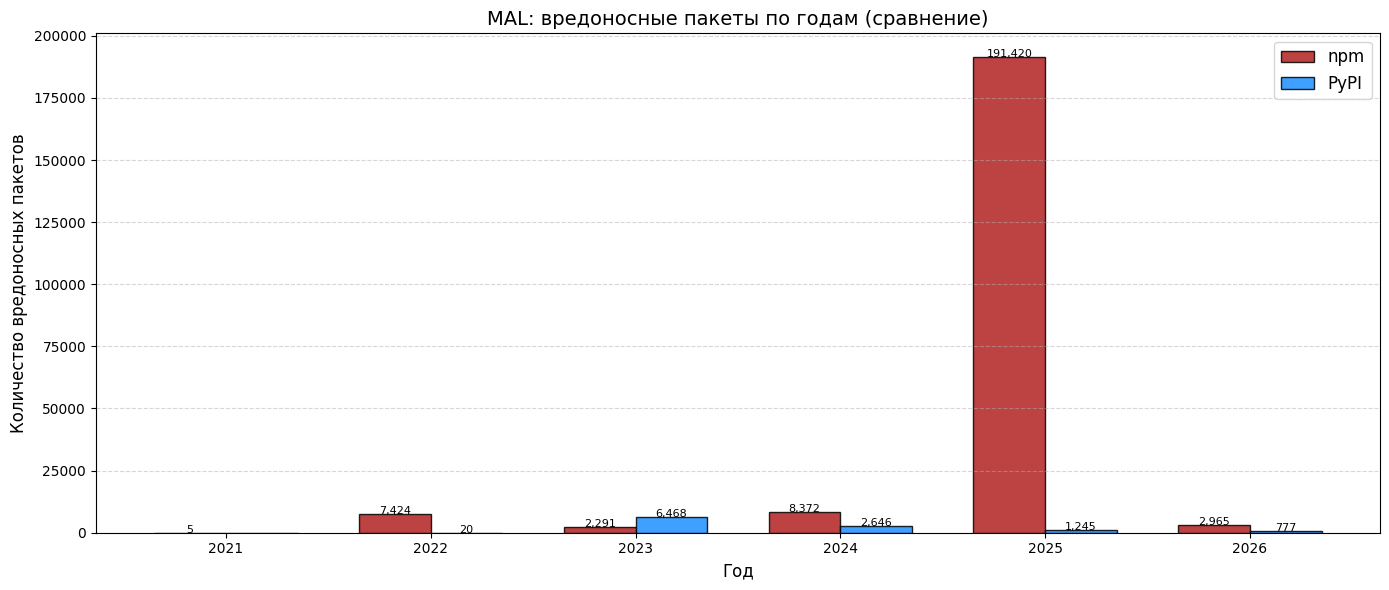

In [25]:
mal_data = combined_vulns[combined_vulns['source'] == 'MAL']


eco_stats = []
yearly_data = {}

for eco in ['npm', 'PyPI']:
    subset = mal_data[mal_data['ecosystem'] == eco]

    # Статистика
    stats = {
        'ecosystem': eco,
        'total': len(subset),
        'with_fix': subset['has_any_fix'].sum(),
        'withdrawn': subset['is_withdrawn'].sum(),
        'avg_refs': subset['references_count'].mean()
    }
    eco_stats.append(stats)

    # По годам
    yearly = subset.groupby('publication_year').size().sort_index()
    yearly = yearly[yearly.index >= 2020]
    yearly_data[eco] = yearly

eco_df = pd.DataFrame(eco_stats)

fig, ax = plt.subplots(figsize=(14, 6))

# Объединяем years
all_years = sorted(set(yearly_data['npm'].index) | set(yearly_data['PyPI'].index))
all_years = [y for y in all_years if y >= 2020]

x = np.arange(len(all_years))
width = 0.35

npm_vals = [yearly_data['npm'].get(y, 0) for y in all_years]
pypi_vals = [yearly_data['PyPI'].get(y, 0) for y in all_years]

bars1 = ax.bar(x - width/2, npm_vals, width, color='firebrick', alpha=0.85,
               label='npm', edgecolor='black')
bars2 = ax.bar(x + width/2, pypi_vals, width, color='dodgerblue', alpha=0.85,
               label='PyPI', edgecolor='black')

# Подписи значений на столбцах
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([int(y) for y in all_years])
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Количество вредоносных пакетов', fontsize=12)
ax.set_title('MAL: вредоносные пакеты по годам (сравнение)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
for eco in ['npm', 'PyPI']:
    subset = mal_data[mal_data['ecosystem'] == eco]
    print(f"{eco}:")
    print(f"  Всего: {len(subset):,}")
    print(f"  С fix: {subset['has_any_fix'].sum():,}")

npm:
  Всего: 212,477
  С fix: 26
PyPI:
  Всего: 11,156
  С fix: 0


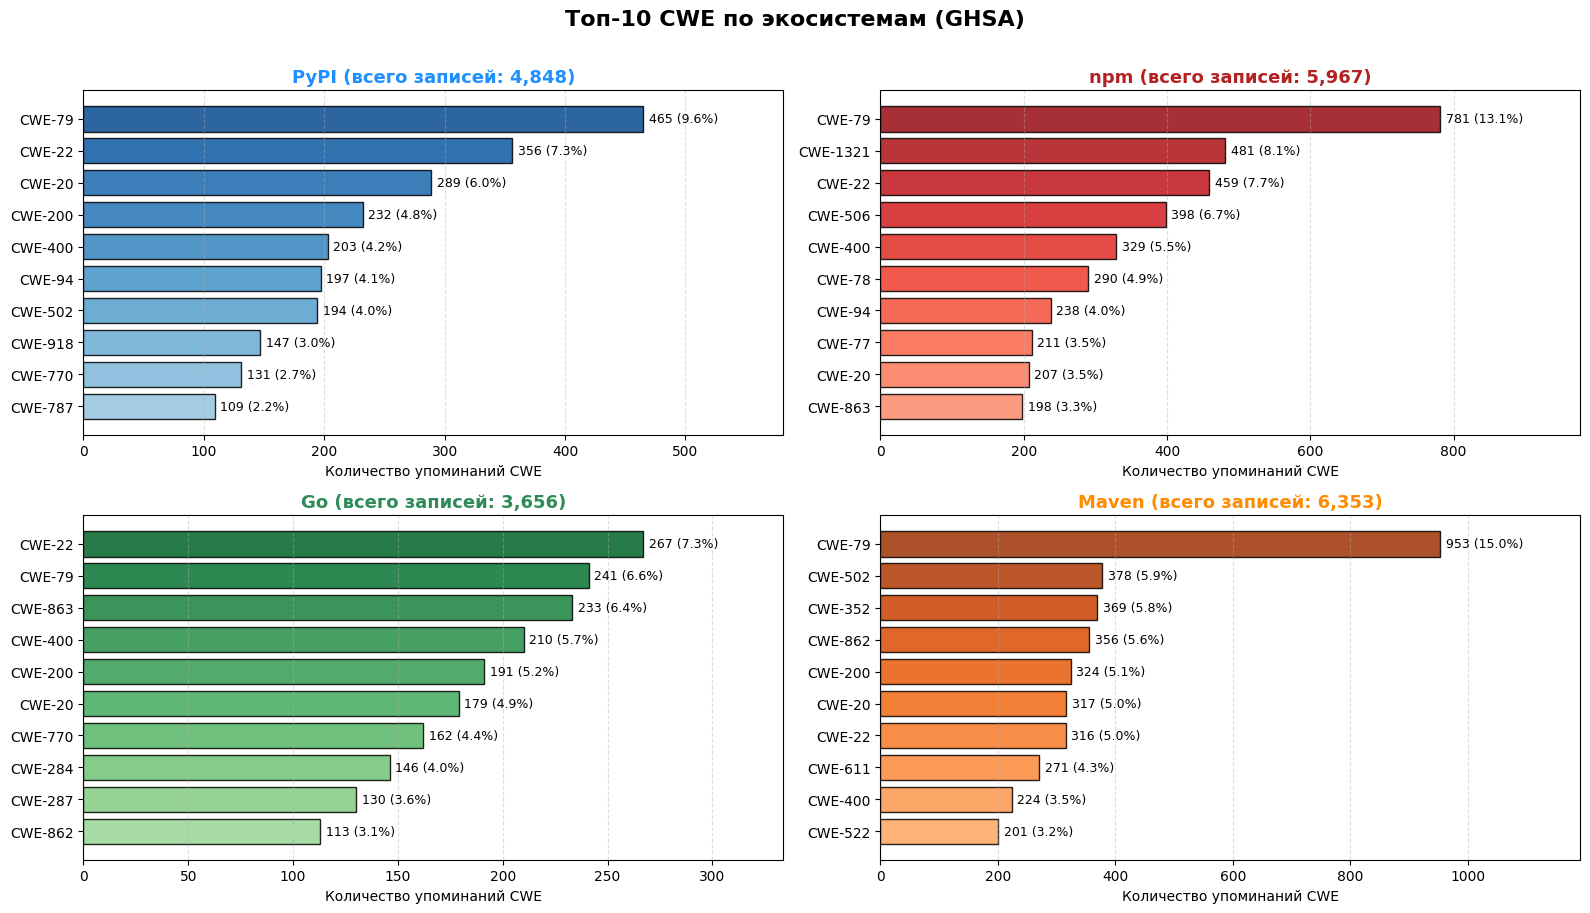

In [27]:
# Подготовка данных

ghsa_with_cwe = combined_vulns[
    (combined_vulns['source'] == 'GHSA') &
    (combined_vulns['cwe_ids'].notna()) &
    (combined_vulns['cwe_ids'] != '') &
    (combined_vulns['ecosystem'].isin(['PyPI', 'npm', 'Go', 'Maven']))
].copy()

# Собираем топ-10 CWE для каждой экосистемы
ecosystems = ['PyPI', 'npm', 'Go', 'Maven']
top_cwe_data = {}

for eco in ecosystems:
    subset = ghsa_with_cwe[ghsa_with_cwe['ecosystem'] == eco]
    all_cwe = []
    for cwe_str in subset['cwe_ids']:
        for cwe in str(cwe_str).split('|'):
            cwe = cwe.strip()
            if cwe:
                all_cwe.append(cwe)

    cwe_counts = Counter(all_cwe)
    top10 = cwe_counts.most_common(10)
    top_cwe_data[eco] = {
        'cwes': [cwe for cwe, _ in top10],
        'counts': [count for _, count in top10],
        'total_records': len(subset)
    }

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# Цвета для экосистем
eco_colors = {
    'PyPI': 'dodgerblue',
    'npm': 'firebrick',
    'Go': 'seagreen',
    'Maven': 'darkorange'
}

for idx, eco in enumerate(ecosystems):
    ax = axes[idx]
    data = top_cwe_data[eco]

    # Сортируем по убыванию (для горизонтальных баров — снизу вверх)
    cwes = data['cwes'][::-1]
    counts = data['counts'][::-1]

    # Создаём градиент цвета (от светлого к тёмному)
    base_color = eco_colors[eco]
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10)) if eco == 'npm' else \
             plt.cm.Blues(np.linspace(0.4, 0.9, 10)) if eco == 'PyPI' else \
             plt.cm.Greens(np.linspace(0.4, 0.9, 10)) if eco == 'Go' else \
             plt.cm.Oranges(np.linspace(0.4, 0.9, 10))

    bars = ax.barh(cwes, counts, color=colors, edgecolor='black', alpha=0.85)

    # Подписи значений и процентов
    for bar, count in zip(bars, counts):
        pct = count / data['total_records'] * 100
        ax.text(bar.get_width() + max(counts)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{count} ({pct:.1f}%)',
                va='center', fontsize=9)

    ax.set_title(f'{eco} (всего записей: {data["total_records"]:,})',
                 fontsize=13, fontweight='bold', color=eco_colors[eco])
    ax.set_xlabel('Количество упоминаний CWE', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_xlim(0, max(counts) * 1.25)

plt.suptitle('Топ-10 CWE по экосистемам (GHSA)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

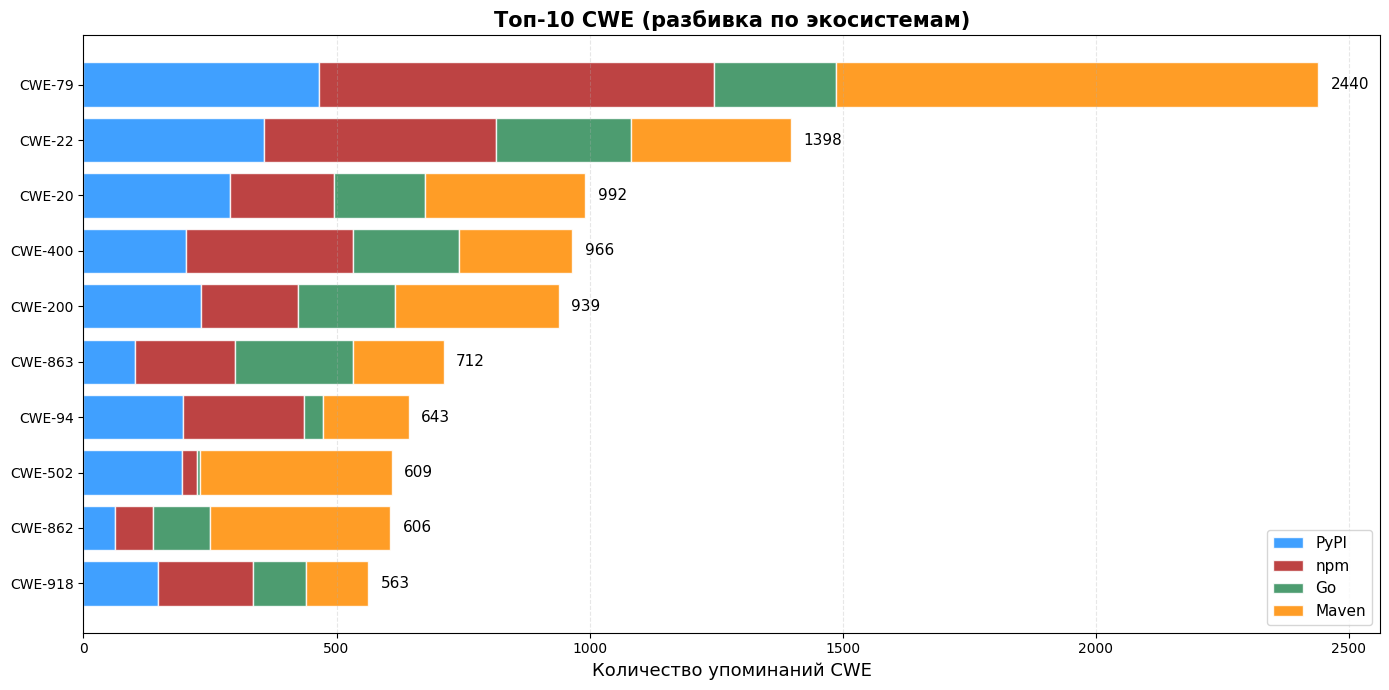

In [28]:
# Общий топ CWE по всем экосистемам
all_cwe_total = []
for cwe_str in ghsa_with_cwe['cwe_ids']:
    for cwe in str(cwe_str).split('|'):
        cwe = cwe.strip()
        if cwe:
            all_cwe_total.append(cwe)

cwe_total_counts = Counter(all_cwe_total)

# Считаем CWE с разбивкой по экосистемам

cwe_eco_counts = defaultdict(lambda: defaultdict(int))

for _, row in ghsa_with_cwe.iterrows():
    eco = row['ecosystem']
    for cwe in str(row['cwe_ids']).split('|'):
        cwe = cwe.strip()
        if cwe:
            cwe_eco_counts[cwe][eco] += 1

# Топ-10 CWE
top10_cwes = [cwe for cwe, _ in cwe_total_counts.most_common(10)]

# Строим stacked horizontal bar
fig, ax = plt.subplots(figsize=(14, 7))

ecos = ['PyPI', 'npm', 'Go', 'Maven']
eco_colors = {'PyPI': 'dodgerblue', 'npm': 'firebrick', 'Go': 'seagreen', 'Maven': 'darkorange'}
bottom = np.zeros(10)

for eco in ecos:
    vals = [cwe_eco_counts[cwe][eco] for cwe in reversed(top10_cwes)]
    ax.barh(list(reversed(top10_cwes)), vals, left=bottom,
            color=eco_colors[eco], alpha=0.85, edgecolor='white', label=eco)
    bottom += vals

# Подписи общих значений
total_vals = [cwe_total_counts[cwe] for cwe in reversed(top10_cwes)]
for i, (cwe, total) in enumerate(zip(reversed(top10_cwes), total_vals)):
    ax.text(total + max(total_vals)*0.01, i, str(total), va='center', fontsize=11)

ax.set_xlabel('Количество упоминаний CWE', fontsize=13)
ax.set_title(f'Топ-10 CWE (разбивка по экосистемам)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Подготовка данных для всех экосистем
ecosystems = ['PyPI', 'npm', 'Go', 'Maven']
colors = {'PyPI': '#2196F3', 'npm': '#FF9800', 'Go': '#4CAF50', 'Maven': '#9C27B0'}

# Собираем CWE по экосистемам
eco_cwe_data = {}
for eco in ecosystems:
    subset = ghsa_with_cwe[ghsa_with_cwe['ecosystem'] == eco]
    all_cwe = []
    for cwe_str in subset['cwe_ids']:
        for cwe in str(cwe_str).split('|'):
            cwe = cwe.strip()
            if cwe:
                all_cwe.append(cwe)
    eco_cwe_data[eco] = Counter(all_cwe)

# Общий топ-10 CWE
all_cwe_total = []
for cwe_str in ghsa_with_cwe['cwe_ids']:
    for cwe in str(cwe_str).split('|'):
        cwe = cwe.strip()
        if cwe:
            all_cwe_total.append(cwe)
total_counts = Counter(all_cwe_total)
top10_total = [cwe for cwe, _ in total_counts.most_common(10)]


# ===== HEATMAP: CWE × ЭКОСИСТЕМА =====
heatmap_data = {}
for cwe in top10_total:
    heatmap_data[cwe] = []
    for eco in ecosystems:
        subset_size = len(ghsa_with_cwe[ghsa_with_cwe['ecosystem'] == eco])
        count = eco_cwe_data[eco].get(cwe, 0)
        heatmap_data[cwe].append(count / subset_size * 100)

fig3 = go.Figure(go.Heatmap(
    z=list(heatmap_data.values()),
    x=ecosystems,
    y=list(heatmap_data.keys()),
    colorscale='YlOrRd',
    text=[[f'{v:.1f}%' for v in row] for row in heatmap_data.values()],
    texttemplate='%{text}',
    colorbar_title="% уязвимостей"
))
fig3.update_layout(
    title="Тепловая карта: CWE × Экосистема",
    height=450
)
fig3.show()

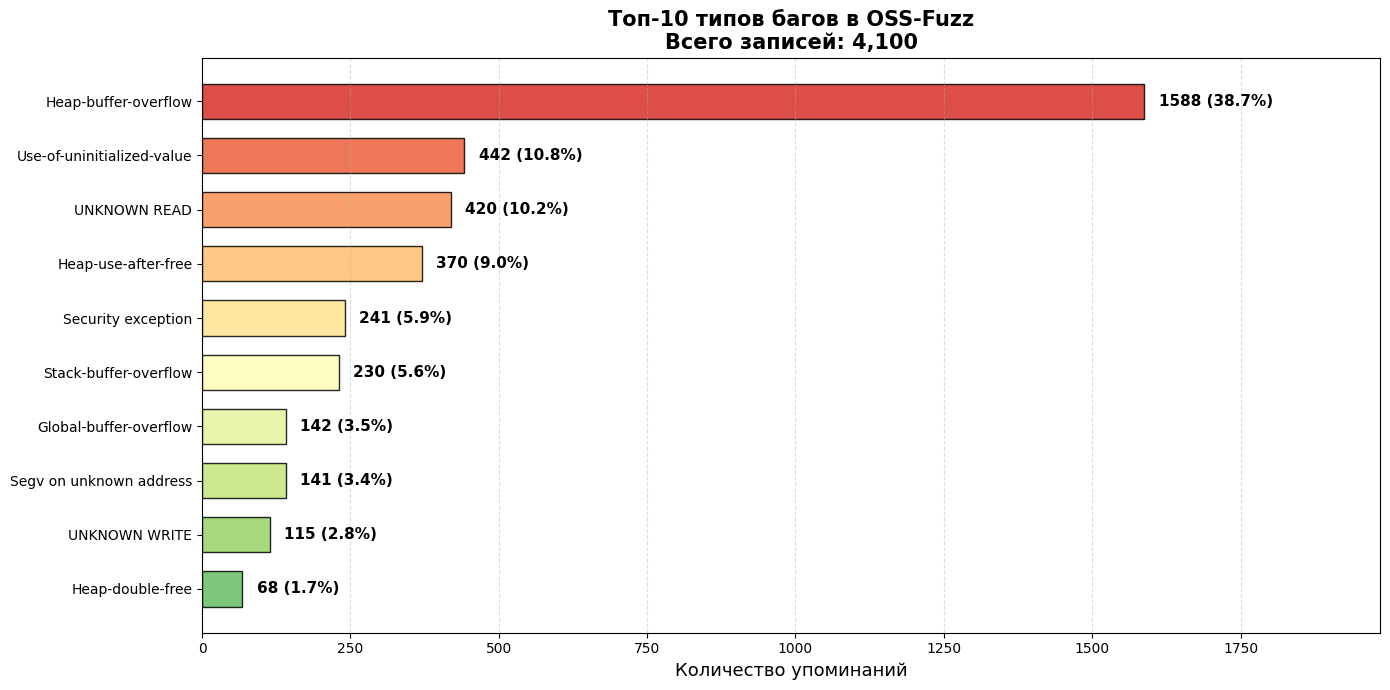

In [30]:
fuzz_vulns = combined_vulns[combined_vulns['ecosystem'] == 'OSS-Fuzz']

crash_types = []
for _, row in fuzz_vulns.iterrows():
    text = str(row['summary']) + ' ' + str(row['details'])
    if 'Crash type:' in text:
        parts = text.split('Crash type:')
        if len(parts) > 1:
            crash = parts[1].split('\n')[0].strip()
            crash_types.append(crash)
    else:
        summary = str(row['summary'])
        if ' in ' in summary:
            crash = summary.split(' in ')[0].strip()
            crash_types.append(crash)

# Очистка crash types
def clean_crash_type(crash):
    cleaned = re.sub(r'\s*(READ|WRITE)\s+\d+', '', crash)
    cleaned = re.sub(r'\s*(READ|WRITE)\s+\{\*\}', '', cleaned)
    cleaned = cleaned.strip()
    return cleaned

cleaned_types = [clean_crash_type(c) for c in crash_types]
cleaned_counts = Counter(cleaned_types)
top10_crashes = cleaned_counts.most_common(10)

# График : Горизонтальные бары
fig, ax = plt.subplots(figsize=(14, 7))

crash_names = [crash for crash, _ in reversed(top10_crashes)]
crash_values = [count for _, count in reversed(top10_crashes)]
total_fuzz = len(fuzz_vulns)

# Цветовая палитра — от опасных (красный) к менее опасным
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 10))

bars = ax.barh(crash_names, crash_values, color=colors, edgecolor='black',
               alpha=0.85, height=0.65)

# Подписи значений и процентов
for bar, count in zip(bars, crash_values):
    pct = count / total_fuzz * 100
    ax.text(bar.get_width() + max(crash_values)*0.015,
            bar.get_y() + bar.get_height()/2,
            f'{count} ({pct:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Количество упоминаний', fontsize=13)
ax.set_title(f'Топ-10 типов багов в OSS-Fuzz\nВсего записей: {total_fuzz:,}',
             fontsize=15, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(crash_values) * 1.25)

# Добавим плашку с самым частым типом
top_crash, top_count = top10_crashes[0]

plt.tight_layout()
plt.show()